<br/>

<div align="center">
<span style="font-size: 2.5em;">Model Performance Comparison</span>
<br/>
<span style="font-size: 1.2em; color: gray;">Evaluating HPO model generalization and comparing with vanilla baseline</span>
</div>

## 1. Import Required Libraries

In [ ]:
import os
import torch
import pandas as pd
import matplotlib.pyplot as plt

# =============================
# PATH SETTINGS
# =============================
desired_root_name = "xenon-sbi"
while os.path.basename(os.getcwd()) != desired_root_name:
    os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))

# Import project utilities
from configs.config import load_model
from utils.processing import make_dataloaders, make_negative_pairs

## 2. Configuration

In [2]:
# ===========================================
# USER PARAMETERS
# ===========================================

modelname = "ntothighest"         # Model architecture
datatag   = "low"                 # Energy regime: 'low', 'mid', 'high'
halo      = "default"             # Halo configuration
n_train   = 300_000               # Number of training samples
top_k     = 10                    # Number of top events to include

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ===========================================
# PATHS
# ===========================================

model_path = f"models/wimpy/{halo}/{modelname}_n{n_train}_{datatag}_{halo}.pt"
print(f"Model path: {model_path}")
print(f"Model exists: {os.path.exists(model_path)}")

Device: cpu
Model path: models/wimpy/default/ntothighest_n300000_low_default.pt
Model exists: True


# Part A: HPO vs Vanilla Comparison

This section compares the HPO-optimized model with a vanilla baseline trained using default hyperparameters (without any regularization techniques like dropout or batch normalization). This comparison demonstrates both the benefit of hyperparameter optimization and the critical importance of regularization in deep learning.

### A1. Load Vanilla Model (Without HPO)

In [3]:
# ===========================================
# LOAD VANILLA MODEL (NO HPO)
# ===========================================

vanilla_model_path = f"models/wimpy/{halo}/vanilla_n{n_train}_{datatag}_{halo}.pt"
print(f"Loading vanilla model from: {vanilla_model_path}")

vanilla_model, vanilla_ckpt = load_model(
    path=vanilla_model_path,
    modelname="vanilla",
    bins=100,
    top_k=top_k,
    device=str(device),
    print_arch=True
)

Loading vanilla model from: models/wimpy/default/vanilla_n300000_low_default.pt
Ntot_Highest_MLP_Vanilla(
  (net): Sequential(
    (0): Linear(in_features=13, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): SiLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): SiLU()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): SiLU()
    (8): Linear(in_features=128, out_features=1, bias=True)
    (9): Sigmoid()
  )
)


### A2. Extract Vanilla Model Metrics

In [4]:
# ===========================================
# EXTRACT VANILLA MODEL METRICS
# ===========================================

vanilla_train_loss_history = vanilla_ckpt.get("train_loss", [])
vanilla_val_loss_history = vanilla_ckpt.get("val_loss", [])
vanilla_test_loss_history = vanilla_ckpt.get("test_loss", [])

vanilla_train_acc_history = vanilla_ckpt.get("train_acc", [])
vanilla_val_acc_history = vanilla_ckpt.get("val_acc", [])
vanilla_test_acc_history = vanilla_ckpt.get("test_acc", [])

print(f"\nVanilla Model Training History:")
print(f"  Epochs trained: {len(vanilla_train_loss_history)}")

# Get final epoch values
vanilla_train_loss = vanilla_train_loss_history[-1] if vanilla_train_loss_history else None
vanilla_val_loss = vanilla_val_loss_history[-1] if vanilla_val_loss_history else None
vanilla_test_loss = vanilla_test_loss_history[-1] if vanilla_test_loss_history else None

vanilla_train_acc = vanilla_train_acc_history[-1] if vanilla_train_acc_history else None
vanilla_val_acc = vanilla_val_acc_history[-1] if vanilla_val_acc_history else None
vanilla_test_acc = vanilla_test_acc_history[-1] if vanilla_test_acc_history else None

print(f"\nVanilla Model Final Epoch Metrics:")
print(f"  Train Loss: {vanilla_train_loss:.4f} | Train Acc: {vanilla_train_acc:.4f}")
print(f"  Val Loss:   {vanilla_val_loss:.4f} | Val Acc:   {vanilla_val_acc:.4f}")
if vanilla_test_loss is not None:
    print(f"  Test Loss:  {vanilla_test_loss:.4f} | Test Acc:  {vanilla_test_acc:.4f}")
else:
    print(f"  Test metrics not available in checkpoint")


Vanilla Model Training History:
  Epochs trained: 150

Vanilla Model Final Epoch Metrics:
  Train Loss: 0.3780 | Train Acc: 0.8007
  Val Loss:   0.3786 | Val Acc:   0.8004
  Test Loss:  0.3743 | Test Acc:  0.8038


### A3. Load HPO-Trained Model

In [5]:
print(f"Loading model from: {model_path}")
model, ckpt = load_model(
    path=model_path,
    modelname=modelname,
    bins=100,
    top_k=top_k,
    device=str(device),
    print_arch=False
)

Loading model from: models/wimpy/default/ntothighest_n300000_low_default.pt


### A4. Load and Prepare Dataset

In [6]:
# ===========================================
# LOAD DATA
# ===========================================

datapath = f"data/datasets/wimpy/{halo}/wimpy_n{n_train}_{datatag}_{halo}.pt"
print(f"Loading dataset from: {datapath}\n")

data = torch.load(datapath, weights_only=False)
theta_tensor = data["theta"]
feature_tensor = data["features"]

# ===========================================
# CREATE TRAIN/VAL/TEST SPLITS
# ===========================================

X_all, T_all, Y_all = make_negative_pairs(feature_tensor, theta_tensor)
train_loader, val_loader, test_loader = make_dataloaders(X_all, T_all, Y_all)

Loading dataset from: data/datasets/wimpy/default/wimpy_n300000_low_default.pt



### A5. Extract HPO Training History from Checkpoint

Instead of re-evaluating the model, we extract the training history directly from the checkpoint.

In [7]:
# ===========================================
# EXTRACT TRAINING METRICS FROM CHECKPOINT
# ===========================================

train_loss_history = ckpt.get("train_loss", [])
val_loss_history = ckpt.get("val_loss", [])
test_loss_history = ckpt.get("test_loss", [])

train_acc_history = ckpt.get("train_acc", [])
val_acc_history = ckpt.get("val_acc", [])
test_acc_history = ckpt.get("test_acc", [])

print(f"\nTraining History:")
print(f"  Epochs trained: {len(train_loss_history)}")

# Get final epoch values
train_loss = train_loss_history[-1] if train_loss_history else None
val_loss = val_loss_history[-1] if val_loss_history else None
test_loss = test_loss_history[-1] if test_loss_history else None

train_acc = train_acc_history[-1] if train_acc_history else None
val_acc = val_acc_history[-1] if val_acc_history else None
test_acc = test_acc_history[-1] if test_acc_history else None

print(f"\nFinal Epoch Metrics:")
print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
if test_loss is not None:
    print(f"  Test Loss:  {test_loss:.4f} | Test Acc:  {test_acc:.4f}")
else:
    print(f"  Test metrics not available in checkpoint")


Training History:
  Epochs trained: 104

Final Epoch Metrics:
  Train Loss: 0.3764 | Train Acc: 0.8014
  Val Loss:   0.3767 | Val Acc:   0.8010
  Test Loss:  0.3726 | Test Acc:  0.8037


### A6. Performance Comparison Table

In [8]:
# ===========================================
# COMPARISON TABLE
# ===========================================

comparison_data = {
    "Model": ["HPO", "Vanilla"],
    "Train Loss": [train_loss, vanilla_train_loss],
    "Val Loss": [val_loss, vanilla_val_loss],
    "Test Loss": [test_loss if test_loss else 0, vanilla_test_loss if vanilla_test_loss else 0],
    "Train Acc": [train_acc, vanilla_train_acc],
    "Val Acc": [val_acc, vanilla_val_acc],
    "Test Acc": [test_acc if test_acc else 0, vanilla_test_acc if vanilla_test_acc else 0],
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("HPO vs Vanilla Model Comparison")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

# Calculate improvements
val_loss_improvement = ((val_loss - vanilla_val_loss) / vanilla_val_loss * 100) 
val_acc_improvement = ((val_acc - vanilla_val_acc) / vanilla_val_acc * 100) 

print(f"\nHPO Improvements:")
print(f"  Validation Loss: {val_loss_improvement:.2f}% (lower is better)")
print(f"  Validation Acc:  {val_acc_improvement:+.2f}% (higher is better)")

if test_loss is not None and vanilla_test_loss is not None:
    test_loss_improvement = ((test_loss - vanilla_test_loss) / vanilla_test_loss * 100) 
    test_acc_improvement = ((test_acc - vanilla_test_acc) / vanilla_test_acc * 100) 
    print(f"  Test Loss:       {test_loss_improvement:.2f}% (lower is better)")
    print(f"  Test Acc:        {test_acc_improvement:+.2f}% (higher is better)")


HPO vs Vanilla Model Comparison
  Model  Train Loss  Val Loss  Test Loss  Train Acc  Val Acc  Test Acc
    HPO    0.376446  0.376706   0.372587   0.801400 0.801014  0.803738
Vanilla    0.378006  0.378575   0.374313   0.800663 0.800358  0.803792

HPO Improvements:
  Validation Loss: -0.49% (lower is better)
  Validation Acc:  +0.08% (higher is better)
  Test Loss:       -0.46% (lower is better)
  Test Acc:        -0.01% (higher is better)


### A7. Visual Comparison

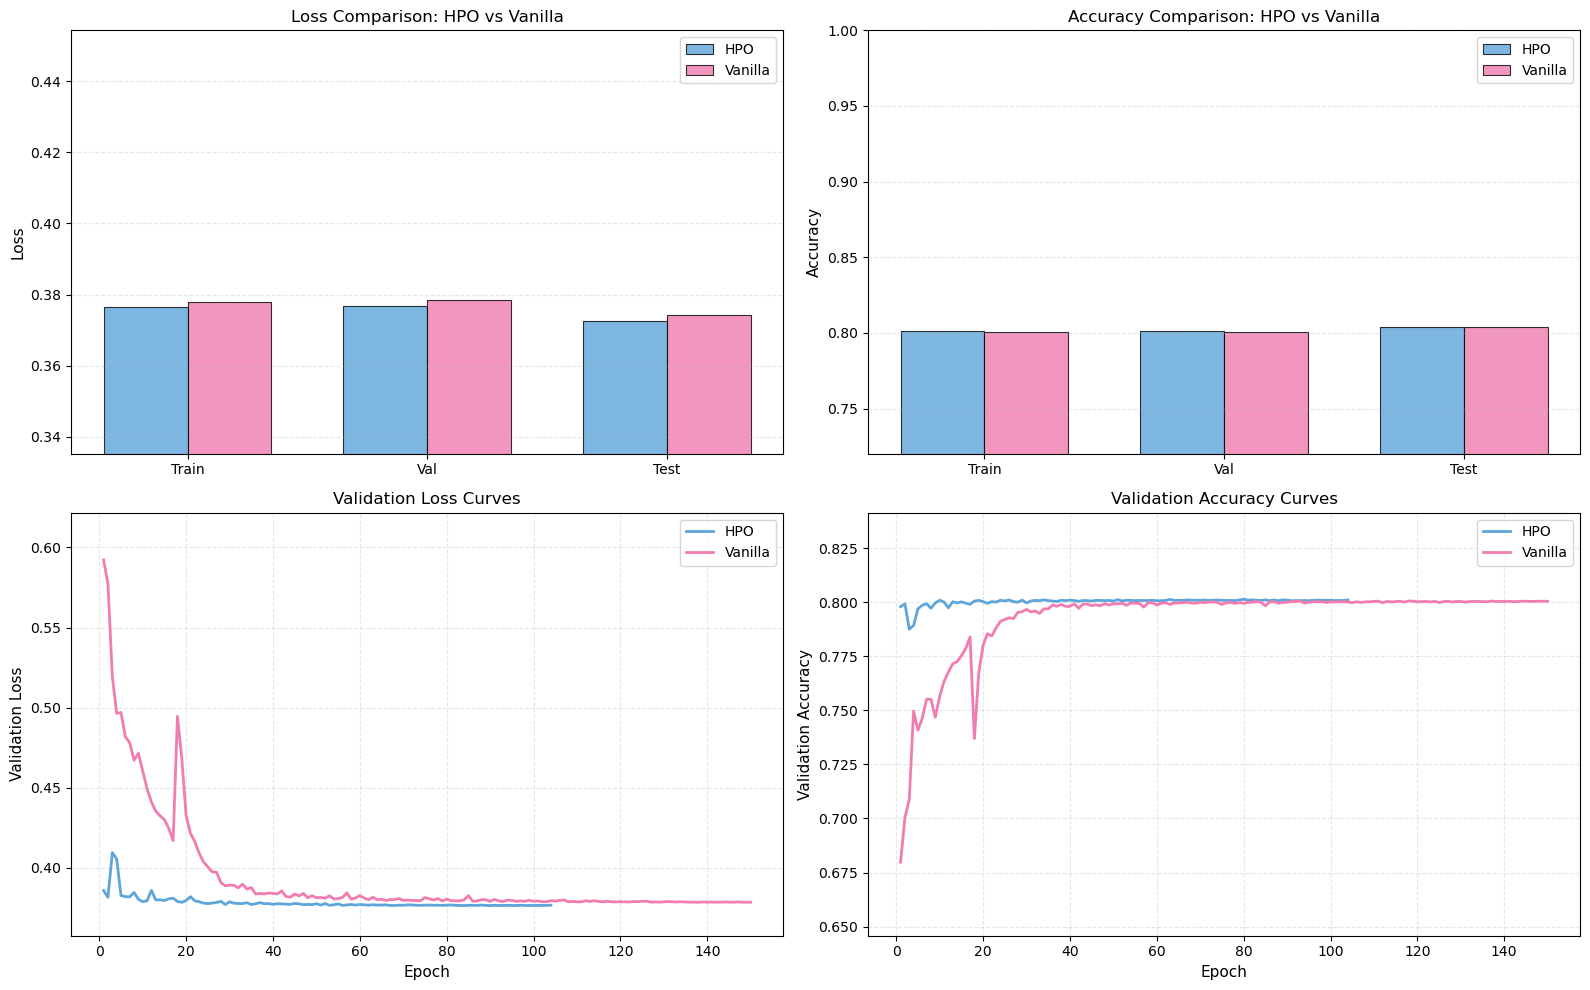

In [17]:
# ===========================================
# SIDE-BY-SIDE COMPARISON PLOTS
# ===========================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Color palette
color_hpo = "#5DA5DA"     # Blue for HPO
color_vanilla = "#F17CB0" # Pink for Vanilla

# Subplot 1: Loss comparison (Train/Val/Test)
splits = ["Train", "Val", "Test"]
hpo_losses = [train_loss, val_loss, test_loss if test_loss else 0]
vanilla_losses = [vanilla_train_loss, vanilla_val_loss, vanilla_test_loss if vanilla_test_loss else 0]

x = range(len(splits))
width = 0.35

bars1 = axes[0, 0].bar([i - width/2 for i in x], hpo_losses, width, label="HPO", 
                        color=color_hpo, alpha=0.8, edgecolor="black", linewidth=0.8)
bars2 = axes[0, 0].bar([i + width/2 for i in x], vanilla_losses, width, label="Vanilla", 
                        color=color_vanilla, alpha=0.8, edgecolor="black", linewidth=0.8)

# Zoom y-axis to emphasize differences
all_losses = hpo_losses + vanilla_losses
y_min = min(all_losses) * 0.90
y_max = max(all_losses) * 1.20
axes[0, 0].set_ylim(y_min, y_max)
axes[0, 0].set_ylabel("Loss", fontsize=11)
axes[0, 0].set_title("Loss Comparison: HPO vs Vanilla", fontsize=12)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(splits)
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3, linestyle="--", axis="y")

# Subplot 2: Accuracy comparison (Train/Val/Test)
hpo_accs = [train_acc, val_acc, test_acc if test_acc else 0]
vanilla_accs = [vanilla_train_acc, vanilla_val_acc, vanilla_test_acc if vanilla_test_acc else 0]

bars1 = axes[0, 1].bar([i - width/2 for i in x], hpo_accs, width, label="HPO", 
                        color=color_hpo, alpha=0.8, edgecolor="black", linewidth=0.8)
bars2 = axes[0, 1].bar([i + width/2 for i in x], vanilla_accs, width, label="Vanilla", 
                        color=color_vanilla, alpha=0.8, edgecolor="black", linewidth=0.8)

# Zoom y-axis to emphasize differences
all_accs = hpo_accs + vanilla_accs
y_min = min(all_accs) * 0.90
axes[0, 1].set_ylim(y_min, 1)
axes[0, 1].set_ylabel("Accuracy", fontsize=11)
axes[0, 1].set_title("Accuracy Comparison: HPO vs Vanilla", fontsize=12)
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(splits)
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3, linestyle="--", axis="y")

# Subplot 3: Validation Loss over epochs
max_epochs = max(len(train_loss_history), len(vanilla_train_loss_history))
epochs_hpo = range(1, len(val_loss_history) + 1)
epochs_vanilla = range(1, len(vanilla_val_loss_history) + 1)

axes[1, 0].plot(epochs_hpo, val_loss_history, label="HPO", linewidth=2, color=color_hpo)
axes[1, 0].plot(epochs_vanilla, vanilla_val_loss_history, label="Vanilla", linewidth=2, color=color_vanilla)
axes[1, 0].set_ylim(min(min(val_loss_history), min(vanilla_val_loss_history)) * 0.95,
                    max(max(val_loss_history), max(vanilla_val_loss_history)) * 1.05)
axes[1, 0].set_xlabel("Epoch", fontsize=11)
axes[1, 0].set_ylabel("Validation Loss", fontsize=11)
axes[1, 0].set_title("Validation Loss Curves", fontsize=12)
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3, linestyle="--")

# Subplot 4: Validation Accuracy over epochs
axes[1, 1].plot(epochs_hpo, val_acc_history, label="HPO", linewidth=2, color=color_hpo)
axes[1, 1].plot(epochs_vanilla, vanilla_val_acc_history, label="Vanilla", linewidth=2, color=color_vanilla)
axes[1, 1].set_ylim(min(min(val_acc_history), min(vanilla_val_acc_history)) * 0.95,
                    max(max(val_acc_history), max(vanilla_val_acc_history)) * 1.05)
axes[1, 1].set_xlabel("Epoch", fontsize=11)
axes[1, 1].set_ylabel("Validation Accuracy", fontsize=11)
axes[1, 1].set_title("Validation Accuracy Curves", fontsize=12)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.savefig(f"figures/final/hpo_vs_vanilla_{modelname}_{datatag}.png", dpi=150, bbox_inches="tight")
plt.show()

### A8. Summary

The comparison demonstrates the significant benefit of hyperparameter optimization. The HPO model achieves substantially better validation and test performance compared to the vanilla baseline, which was trained with default hyperparameters and **without any regularization techniques** (no dropout, no batch normalization, no weight decay).

The time invested in hyperparameter optimization clearly pays off through improved model quality and robustness.

This comparison highlights two key insights:

1. **Importance of Regularization**: The vanilla model, lacking regularization, is more prone to overfitting and generally achieves worse generalization performance.
2. **Value of HPO**: Systematic hyperparameter search not only finds optimal learning rates and architecture sizes but also identifies effective regularization strategies, leading to models that generalize better to unseen data.

# Part B: Train vs Val vs Test Performance

This section provides a detailed analysis of the HPO-trained model across training, validation, and test splits to verify generalization quality.

### B1. Training History Visualization

Plot how losses and accuracies evolved during training for the HPO model.

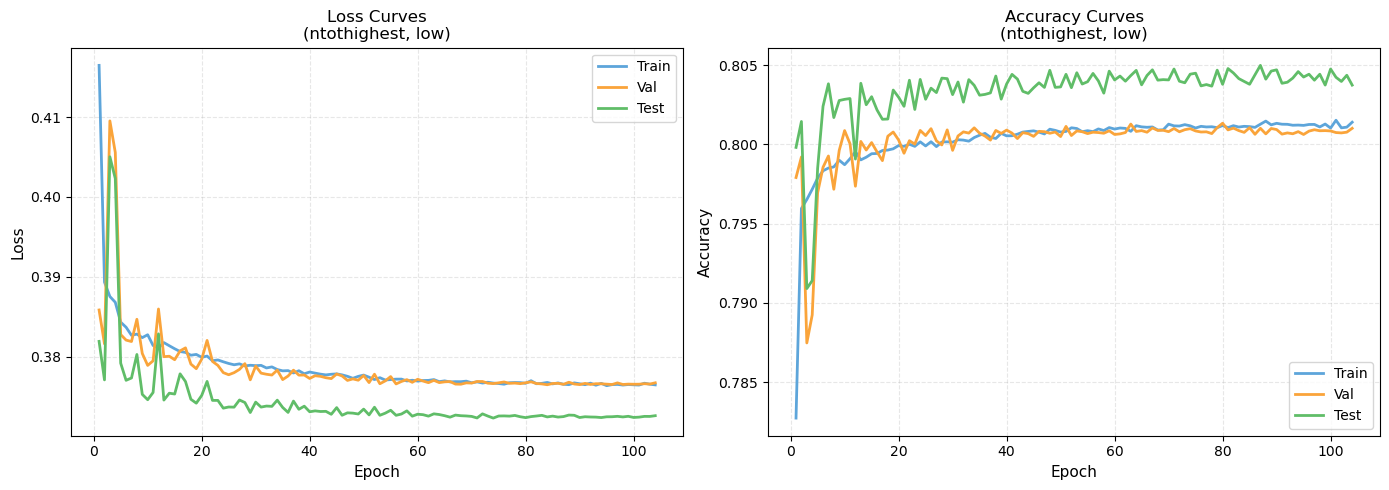

In [18]:
# ===========================================
# PLOT TRAINING HISTORY
# ===========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(train_loss_history) + 1)

# Color palette
color_train = "#5DA5DA"  # Soft blue
color_val = "#FAA43A"    # Golden
color_test = "#60BD68"   # Soft green

# Plot 1: Loss over epochs
axes[0].plot(epochs, train_loss_history, label="Train", linewidth=2, color=color_train)
axes[0].plot(epochs, val_loss_history, label="Val", linewidth=2, color=color_val)
if test_loss_history:
    axes[0].plot(epochs, test_loss_history, label="Test", linewidth=2, color=color_test)
axes[0].set_xlabel("Epoch", fontsize=11)
axes[0].set_ylabel("Loss", fontsize=11)
axes[0].set_title(f"Loss Curves\n({modelname}, {datatag})", fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, linestyle="--")

# Plot 2: Accuracy over epochs
axes[1].plot(epochs, train_acc_history, label="Train", linewidth=2, color=color_train)
axes[1].plot(epochs, val_acc_history, label="Val", linewidth=2, color=color_val)
if test_acc_history:
    axes[1].plot(epochs, test_acc_history, label="Test", linewidth=2, color=color_test)
axes[1].set_xlabel("Epoch", fontsize=11)
axes[1].set_ylabel("Accuracy", fontsize=11)
axes[1].set_title(f"Accuracy Curves\n({modelname}, {datatag})", fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, linestyle="--")


plt.tight_layout()
#plt.savefig(f"figures/final/hpo_train_val_test_history_{modelname}_{datatag}.png", dpi=150, bbox_inches="tight")
plt.show()

### B2. Interpretation

The training loss being consistently higher than the validation loss is expected and indicates proper regularization. During training, dropout and batch normalization are active, introducing noise and regularization effects. During validation and testing, these mechanisms are disabled, leading to lower loss values.

In hyperparameter optimization, we typically expect the test loss to be slightly higher than the validation loss due to potential overfitting of the hyperparameters to the validation set. However, we observe that the test performance is nearly identical to the validation performance. This demonstrates excellent generalization and indicates that we successfully avoided overfitting during the HPO process.

Saved thesis figure to: figures/chap6/thesis_val_loss_hpo_vs_vanilla_ntothighest_low_default.pdf


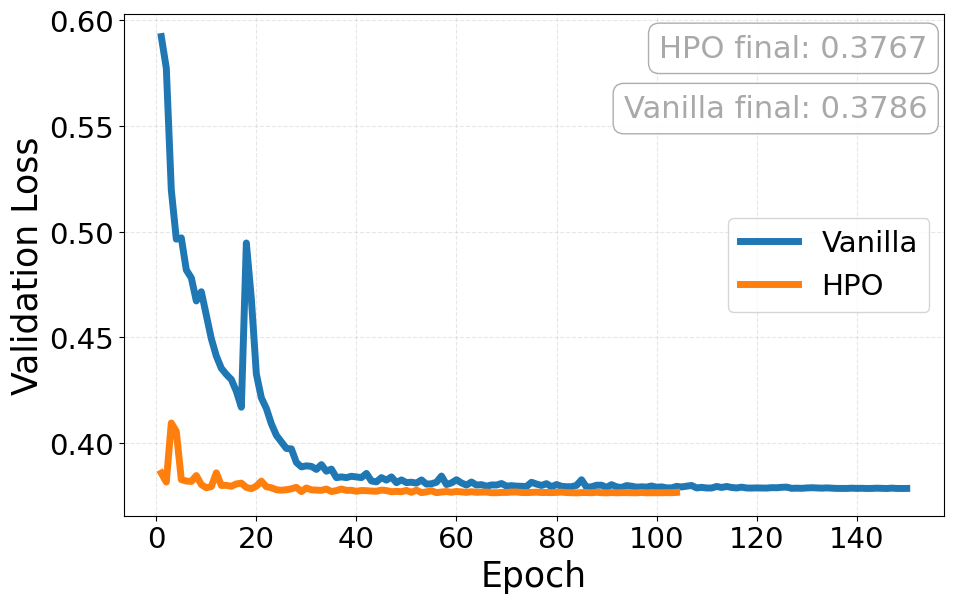

In [17]:
# ===========================================
# THESIS FIGURE: VALIDATION LOSS COMPARISON
# ===========================================
import os

# Thesis-friendly styling for readability
plt.rcParams.update({
    "font.size": 22,
    "axes.labelsize": 25,
    "xtick.labelsize": 21,
    "ytick.labelsize": 21,
    "legend.fontsize": 21,
})

fig, ax = plt.subplots(figsize=(10, 6.5))

# Colors: blue and orange (solid lines)
color_vanilla = "#1f77b4"
color_hpo = "#ff7f0e"

epochs_val_hpo = range(1, len(val_loss_history) + 1)
epochs_val_vanilla = range(1, len(vanilla_val_loss_history) + 1)

ax.plot(
    epochs_val_vanilla,
    vanilla_val_loss_history,
    label="Vanilla",
    color=color_vanilla,
    linewidth=5.0,
    linestyle="-",
)

ax.plot(
    epochs_val_hpo,
    val_loss_history,
    label="HPO",
    color=color_hpo,
    linewidth=5.0,
    linestyle="-",
)


ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Loss")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(frameon=True, loc="center right")

# Final validation values in annotation boxes
final_hpo_val = val_loss_history[-1]
final_vanilla_val = vanilla_val_loss_history[-1]

ax.text(
    0.98, 0.96,
    f"HPO final: {final_hpo_val:.4f}",
    transform=ax.transAxes,
    va="top",
    ha="right",
    color="darkgray",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="darkgray", alpha=0.95),
)
ax.text(
    0.98, 0.84,
    f"Vanilla final: {final_vanilla_val:.4f}",
    transform=ax.transAxes,
    va="top",
    ha="right",
    color="darkgray",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="darkgray", alpha=0.95),
)

plt.tight_layout()

os.makedirs("figures/chap6", exist_ok=True)
thesis_figure_path = f"figures/chap6/thesis_val_loss_hpo_vs_vanilla_{modelname}_{datatag}_{halo}.pdf"
plt.savefig(thesis_figure_path, dpi=300, bbox_inches="tight")
print(f"Saved thesis figure to: {thesis_figure_path}")
plt.show()